# K-Means Clustering
An algorithm that groups data into clusters by finding the nearest center

In [1]:
print("hello")

hello


In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris

In [29]:
url = 'https://raw.githubusercontent.com/uiuc-cse/data-fa14/gh-pages/data/iris.csv'
df = pd.read_csv(url)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [31]:
X = df[['sepal_length','sepal_width','petal_length','petal_width']]
X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Scale the features

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[-0.90068117,  1.03205722, -1.3412724 , -1.31297673],
       [-1.14301691, -0.1249576 , -1.3412724 , -1.31297673],
       [-1.38535265,  0.33784833, -1.39813811, -1.31297673],
       [-1.50652052,  0.10644536, -1.2844067 , -1.31297673],
       [-1.02184904,  1.26346019, -1.3412724 , -1.31297673]])

# Fit a K-Means clustering model

In [33]:
kmeans = KMeans(n_clusters=3, random_state=1, n_init='auto')
kmeans.fit(X_scaled)

cluster_labels = kmeans.labels_

## Compare cluster to true species labels

In [35]:
df["cluster"] = cluster_labels
crosstab = pd.crosstab(df['cluster'],df['species'])
crosstab

species,setosa,versicolor,virginica
cluster,,,
0,1,37,8
1,49,0,0
2,0,13,42


### Visualize clusters in featue space

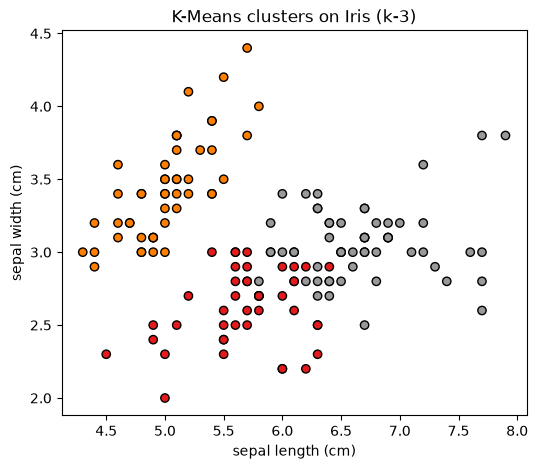

In [36]:
plt.figure(figsize=(6,5))
scatter = plt.scatter(
    df["sepal_length"],
    df["sepal_width"],
    c = df["cluster"],
    cmap=plt.cm.Set1,
    edgecolors="k"
)


plt.xlabel("sepal length (cm)")
plt.ylabel("sepal width (cm)")
plt.title("K-Means clusters on Iris (k-3)")
plt.show()

# Inertia

A measure of how closely points in a cluster group around their center.

Adding more clusters reduces inertia, but benefits decrease over time

## choose the number of clusters using hte "Elbow Method"

#### Elbow Method
A way to find the best number of clusters by spotting a curve in a plt


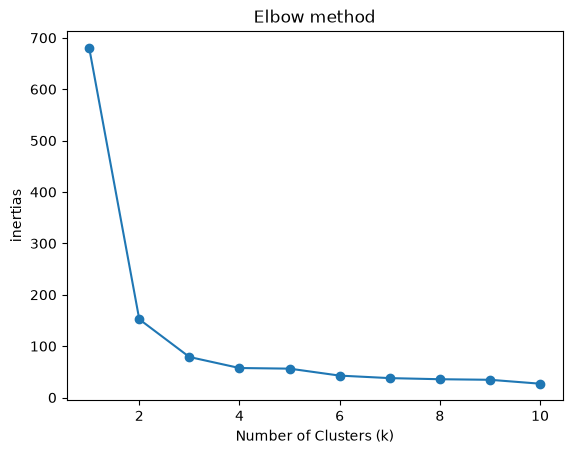

In [38]:
inertias = []
for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=1)
    km.fit(X)
    inertias.append(km.inertia_)

plt.plot(range(1,11), inertias, marker = 'o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("inertias")
plt.title("Elbow method")
plt.show()